In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
sys.path.append('../results')

In [243]:
pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)
#  pkg_path='' # replace with local directory if needed
data_path=pkg_path+'/functional_results/'

DSC_ED_file_name='shap_DSC_ap_rCBV_ED.csv'
DTI_NC_file_name='shap_DTI_AD_NC_.csv'
DTI_ET_file_name='shap_DTI_AD_ET_.csv'

shap_DSC=pd.read_csv(data_path+DSC_ED_file_name)
shap_DTI_NC=pd.read_csv(data_path+DTI_NC_file_name)

FNN_file_name='model_results_summary_for_Linear_Model.csv'

FNN_model_stats=pd.read_csv(data_path+FNN_file_name)
FNN_model_stats.sort_values(by='best_r2', ascending=False, inplace=True)
FNN_model_stats.head()


,file_name,mse_avg,mse_std,r2_avg,r2_std,mse,r2,best_model_filename,best_r2
42,Radiomic_Features_CaPTk_segm_DSC_ap-rCBV_ED.csv,113832.973437,26674.540265,-0.337353,0.757463,"[101211.0625, 101381.9765625, 149219.328125, 7...","[0.53214430809021, -1.6663684844970703, -0.308...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.532144
21,Radiomic_Features_CaPTk_segm_DTI_AD_NC.csv,150960.212500,74801.254338,-0.623397,0.776163,"[87997.671875, 138334.90625, 296821.59375, 123...","[-0.28283143043518066, -2.05607271194458, -0.5...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.285185
14,Radiomic_Features_CaPTk_automaticsegm_DSC_ap-r...,149921.679688,30233.591665,0.039820,0.120156,"[154401.390625, 123462.6484375, 172005.6875, 1...","[-0.12214720249176025, 0.22789400815963745, -0...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.227894
29,Radiomic_Features_CaPTk_segm_DTI_FA_ED.csv,152228.147656,73566.890357,-0.233849,0.356527,"[51533.95703125, 134610.609375, 195068.3125, 1...","[-0.7542406320571899, -0.13952744007110596, 0....",best_linear_model_for_Radiomic_Features_CaPTk_...,0.203358
38,Radiomic_Features_CaPTk_segm_DTI_RD_ED.csv,138706.848438,52276.030156,-0.191680,0.409855,"[58387.203125, 129199.8359375, 203639.625, 115...","[-0.9875284433364868, -0.09372329711914062, 0....",best_linear_model_for_Radiomic_Features_CaPTk_...,0.186497


In [244]:
file_type_mapping = {
    'DTI': 1,
    'DSC': 2,
    'T2': 3,
    'Flair': 4,
    'T1': 5,
    'T1GD': 6
}

# Define colors for 'NC', 'ET', 'ED'
def get_color(file_name):
    if 'NC' in file_name:
        return 'red'
    elif 'ET' in file_name:
        return 'blue'
    elif 'ED' in file_name:
        return 'green'
    return 'black'  

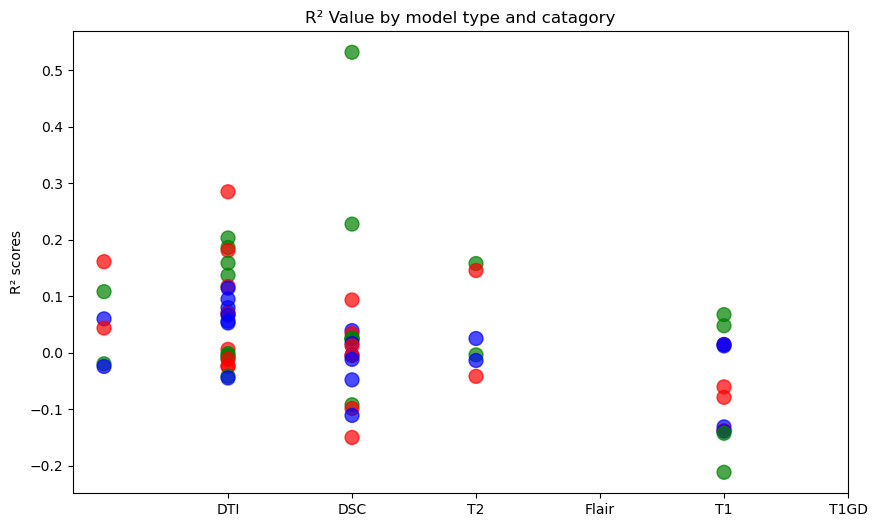

In [245]:
df=FNN_model_stats
# Mapping the 'file_name' to x-axis positions and colors
df['file_type'] = df['file_name'].apply(lambda x: next((key for key in file_type_mapping if key in x), 'Unknown'))
df['x_position'] = df['file_type'].apply(lambda x: file_type_mapping.get(x, 0))
df['color'] = df['file_name'].apply(get_color)

plt.figure(figsize=(10, 6))

plt.scatter(df['x_position'], df['best_r2'], c=df['color'], s=100, alpha=0.7)
plt.xticks(list(file_type_mapping.values()), list(file_type_mapping.keys()))

plt.ylabel('R² scores')
plt.title('R² Value by model type and catagory')
plt.grid(False)
plt.show()

In [246]:

shap_DSC.sort_values(by='Summed_Shapy_Values',ascending=False, inplace=True)
shap_DTI_NC.sort_values(by='Summed_Shapy_Values',ascending=False, inplace=True)

shap_DSC['Unnamed: 0'] = shap_DSC['Unnamed: 0'].str.replace('DSC_ap-rCBV_ED_', '', regex=False)
shap_DTI_NC['Unnamed: 0'] = shap_DTI_NC['Unnamed: 0'].str.replace('DTI_AD_NC_', '', regex=False)


In [247]:

# Cutoff determines the shap values in which to drop if beneath
cutoff=200

DTI_NC = shap_DTI_NC.reset_index()


DTI_df =DTI_NC[DTI_NC['Summed_Shapy_Values'] >= cutoff]

DSC_df=shap_DSC[(shap_DSC['Summed_Shapy_Values']  >= cutoff)]

DSC_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)
DTI_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)

DTI_df2=DTI_df['Selected_features']
DSC_df2=DSC_df['Selected_features']

DSC_df.set_index('Selected_features', inplace=True)
DTI_df.set_index('Selected_features', inplace=True)

DSC_df=DSC_df['Summed_Shapy_Values']
DTI_df=DTI_df['Summed_Shapy_Values']

DTI_df.head()

/tmp/ipykernel_2841590/3354637600.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DSC_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)
/tmp/ipykernel_2841590/3354637600.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DTI_df.rename(columns={'Unnamed: 0': 'Selected_features'}, inplace=True)


Selected_features
Histogram_Bins-16_Bins-16_NinetiethPercentile    519.663175
Histogram_Bins-16_Bins-16_Entropy                518.207935
NGTDM_Complexity                                 471.553385
Intensity_Mean                                   436.947338
Histogram_Bins-16_Bins-16_Bin-10_Probability     436.786279
Name: Summed_Shapy_Values, dtype: float64

In [248]:
DTI_df2.to_csv(data_path+'selected_features_DTI.csv', header=True)
DSC_df2.to_csv(data_path+'selected_features_DSC.csv', header=True)

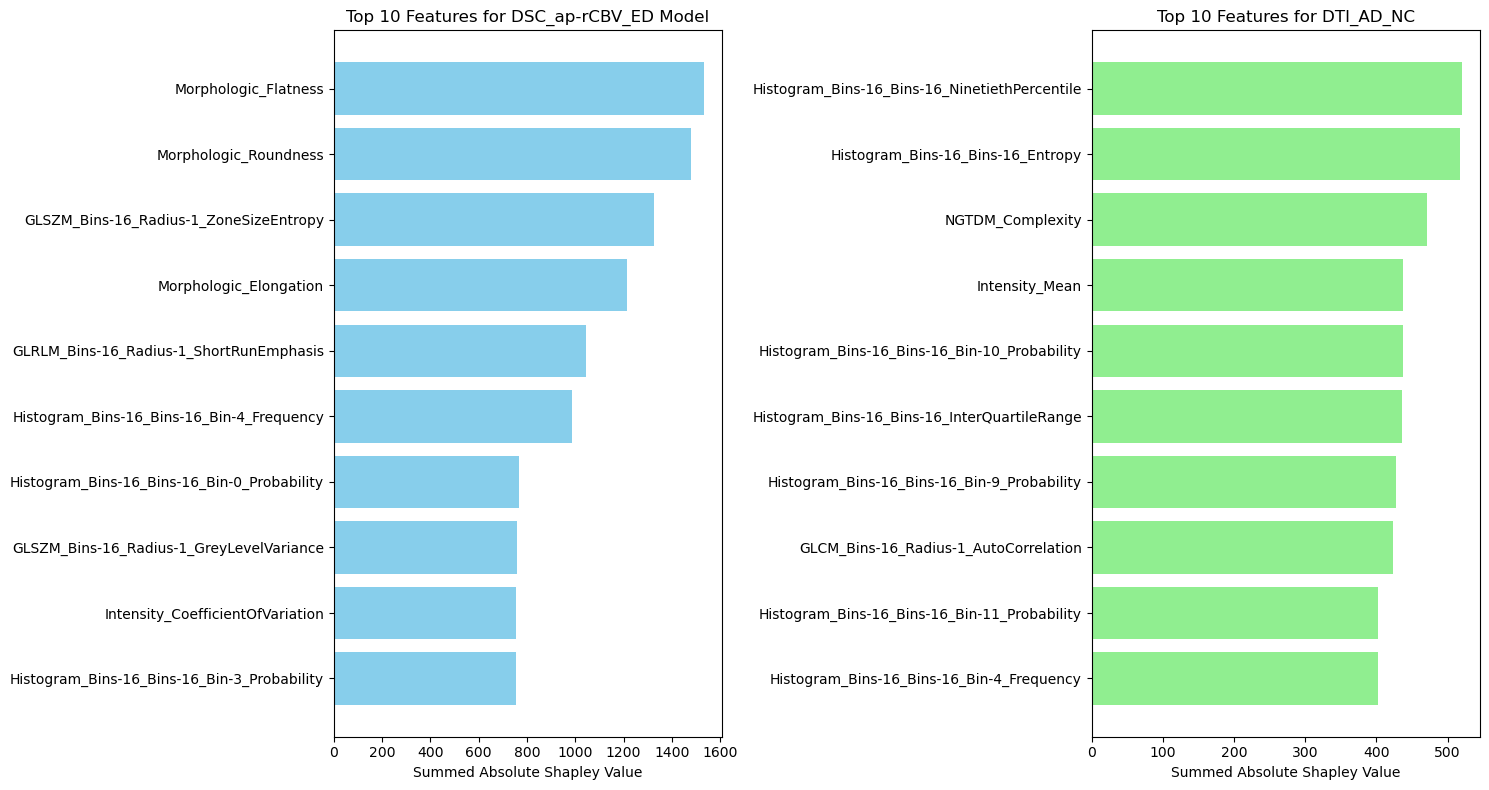

In [249]:
num_top_features = 10

# Gets the top `num_top_features` based on the summed Shapley values
top_features_DSC = DSC_df.nlargest(num_top_features)
top_features_DTI = DTI_df.nlargest(num_top_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot for DSC model
axes[0].barh(top_features_DSC.index, top_features_DSC.values, color='skyblue')
axes[0].set_xlabel('Summed Absolute Shapley Value')
axes[0].set_title(f'Top {num_top_features} Features for DSC_ap-rCBV_ED Model')
axes[0].invert_yaxis()  

# Plot for DTI model
axes[1].barh(top_features_DTI.index, top_features_DTI.values, color='lightgreen')
axes[1].set_xlabel('Summed Absolute Shapley Value')
axes[1].set_title(f'Top {num_top_features} Features for DTI_AD_NC')
axes[1].invert_yaxis()  

plt.tight_layout()
plt.show()


In [250]:
# Loads survival data
surv_path = data_path+'Survival_data.csv'
Z=pd.read_csv(surv_path)['0']
Z.head()

0     960.0
1     291.0
2    2838.0
3     623.0
4    1143.0
Name: 0, dtype: float64

In [251]:
Z_log=np.log(Z)
Z_log_norm = (Z_log - np.mean(Z_log)) / np.std(Z_log)
t_half=np.mean(Z_log)
lambda_value=np.log(2)/t_half
Z_norm=np.exp(-Z_log_norm*lambda_value)
Z_norm=(Z_norm-np.mean(Z_norm))
print(lambda_value)

0.11913540154196517


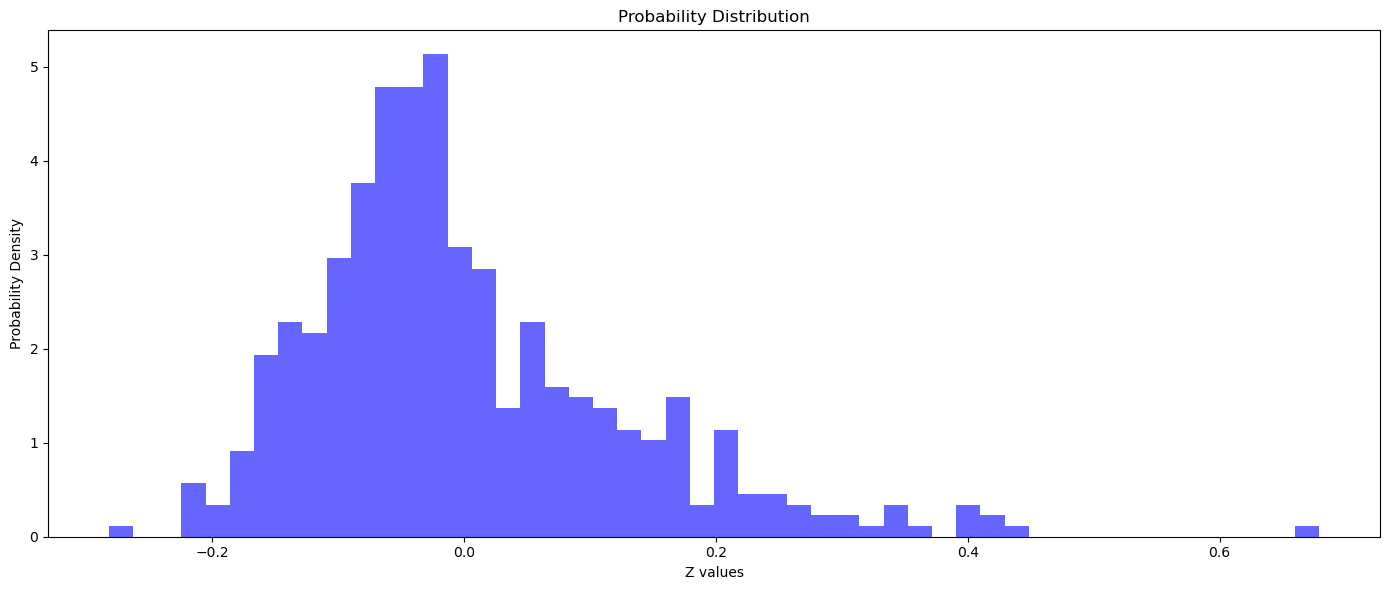

In [252]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Plot Probability Distribution
axes.hist(Z_norm, bins=50, density=True, alpha=0.6, color='blue')
axes.set_title('Probability Distribution')
axes.set_xlabel('Z values')
axes.set_ylabel('Probability Density')

plt.tight_layout()
plt.show()

In [253]:
valid_indices = abs(Z_norm) <= 0.3
Z_norm = Z_norm[valid_indices]
Z_norm = Z_norm.to_numpy()
scaler = MinMaxScaler()
Z_scaled = scaler.fit_transform(Z_norm.reshape(-1, 1))

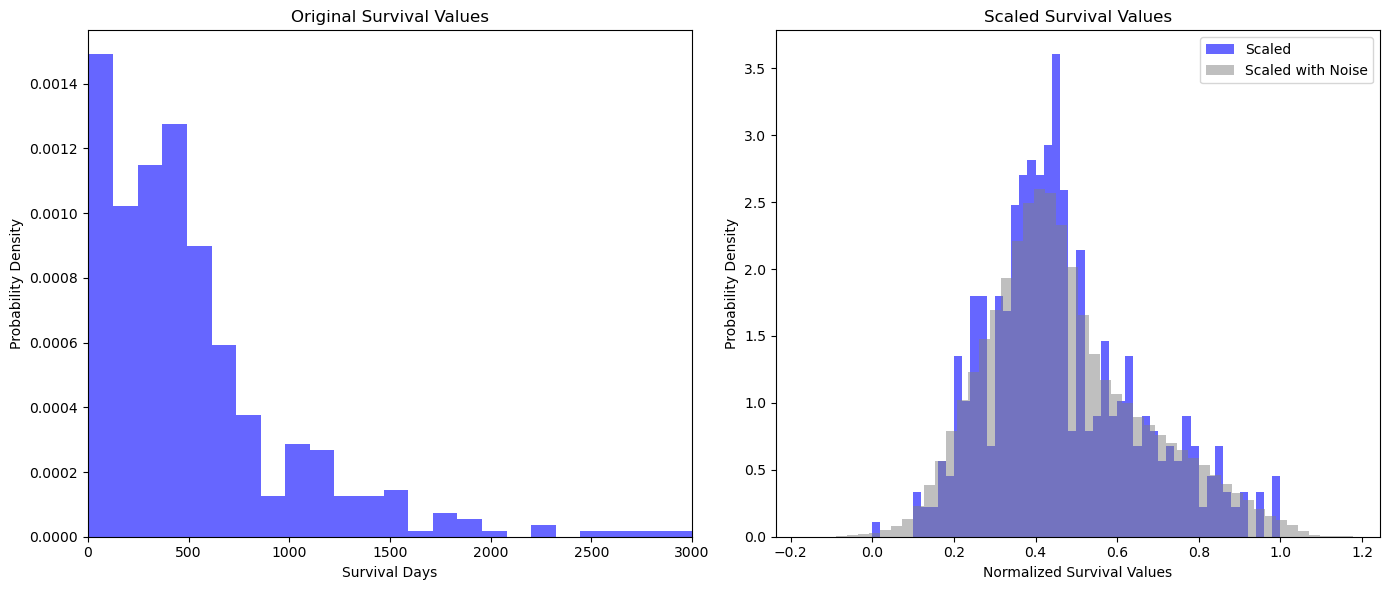

In [254]:
def add_noise_to_labels(labels, noise_factor=0.05, seed=None):
    """
    Adds Gaussian noise to each label individually.
    
    Args:
        labels (array-like): The array of labels (Z values) to which noise is added.
        noise_factor (float): The factor by which noise is scaled.
        seed (int, optional): A seed for randomness to control noise addition (default is None).
        
    Returns:
        numpy.ndarray: Labels with added/subtracted noise.
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Generate Gaussian noise for each label
    noise = np.random.randn(len(labels)) * noise_factor  # Generate noise for each label
    
    # Add or subtract noise randomly for each label
    noisy_labels = labels + noise * (np.random.choice([-1, 1], size=len(labels)))  # Add or subtract
    
    return noisy_labels

# Adding noise to Z_scaled
Z_scaled_with_noise = add_noise_to_labels(Z_scaled, noise_factor=0.05)
Z_scaled_with_noise = Z_scaled_with_noise.flatten()
# Create the figure with two subplots (1x2 grid)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original Z values (without scaling or noise)
axes[0].hist(Z, bins=50, density=True, alpha=0.6, color='blue')
axes[0].set_title('Original Survival Values')
axes[0].set_xlabel('Survival Days')
axes[0].set_ylabel('Probability Density')
axes[0].set_xlim([0, 3000])

# Plot both Z_scaled and Z_scaled_with_noise on the same plot (second subplot)
axes[1].hist(Z_scaled, bins=50, density=True, alpha=0.6, color='blue', label='Scaled')
axes[1].hist(Z_scaled_with_noise, bins=50, density=True, alpha=0.5, color='gray', label='Scaled with Noise')
axes[1].set_title('Scaled Survival Values')
axes[1].set_xlabel('Normalized Survival Values')
axes[1].set_ylabel('Probability Density')
axes[1].legend()

# Show the plots
plt.tight_layout()
plt.show()

In [255]:
saliency_maps_file = data_path+'saliency_maps.pkl'

with open(saliency_maps_file, 'rb') as f:
    saliency_maps = pickle.load(f)

print("Saliency maps loaded successfully!")

Saliency maps loaded successfully!


In [256]:
def extract_first_batch_for_plotting(saliency_maps):
    first_batch_maps = {}
    
    # Extract the first batch (batch_0) for each key
    for key, value in saliency_maps.items():
        if 'batch_0' in key:
            first_batch_maps[key] = value
    
    return first_batch_maps
first_batch_saliency_maps = extract_first_batch_for_plotting(saliency_maps)


In [257]:
saliency_maps.keys()

dict_keys(['1_f_saliency_map_batch_0_0', '1_f_saliency_map_batch_0_1', '1_f_saliency_map_batch_0_2', '1_f_saliency_map_batch_0_3', '1_f_saliency_map_batch_0_4', '1_f_saliency_map_batch_0_5', '1_f_saliency_map_batch_0_6', '1_f_saliency_map_batch_0_7', '1_f_saliency_map_batch_0_8', '1_f_saliency_map_batch_0_9', '1_f_saliency_map_batch_0_10', '1_f_saliency_map_batch_0_11', '1_f_saliency_map_batch_0_12', '1_f_saliency_map_batch_0_13', '1_f_saliency_map_batch_0_14', '1_f_saliency_map_batch_0_15', '1_f_saliency_map_batch_1_0', '1_f_saliency_map_batch_1_1', '1_f_saliency_map_batch_1_2', '1_f_saliency_map_batch_1_3', '1_f_saliency_map_batch_1_4', '1_f_saliency_map_batch_1_5', '1_f_saliency_map_batch_1_6', '1_f_saliency_map_batch_1_7', '1_f_saliency_map_batch_1_8', '1_f_saliency_map_batch_1_9', '1_f_saliency_map_batch_1_10', '1_f_saliency_map_batch_1_11', '1_f_saliency_map_batch_1_12', '1_f_saliency_map_batch_1_13', '1_f_saliency_map_batch_1_14', '1_f_saliency_map_batch_1_15', '1_f_saliency_map

In [258]:
def extract_images_for_batch(saliency_maps, original_images, batch_pattern='batch_0_10'):
    """
    Extracts the saliency maps and corresponding original images for the four combinations of 
    model (1/2) and label type (f/s), based on the batch pattern.
    
    Parameters:
        saliency_maps (dict): Dictionary of saliency maps.
        original_images (dict): Dictionary of original images.
        batch_pattern (str): Pattern to match batch in the keys.
    
    Returns:
        extracted_images (list of dicts): List containing extracted data for each model-type + label-type combination.
    """
    # Define mappings for more meaningful names
    model_names = {'1': 'DSC', '2': 'DTI'}
    label_names = {'f': 'Features', 's': 'Survival'}

    extracted_images = []

    # Iterate over all combinations of model and label types
    for model_key in ['1', '2']:
        for label_type in ['f', 's']:
            # Create the batch key based on the current model and label type
            pattern = f'{model_key}_{label_type}_saliency_map_{batch_pattern}'
            
            # Find matching saliency map keys for this pattern
            matching_keys = [key for key in saliency_maps.keys() if pattern in key]
            
            if matching_keys:
                # Pick the first matching key (you could select others as needed)
                batch_key = matching_keys[0]
                value = saliency_maps[batch_key]
                saliency_map = value['saliency_map']
                original_image = original_images[batch_key]['image']  # Extract corresponding original image

                # Store extracted images and saliency maps along with their labels
                extracted_images.append({
                    'saliency_map': saliency_map,# correcting for accidently flipping earlier
                    'original_image': original_image,
                    'model_name': model_names[model_key],
                    'label_name': label_names[label_type]
                })
            else:
                print(f"No matching batch found for pattern '{pattern}'")

    return extracted_images

In [259]:
batch_pattern = 'batch_3_1'  # Modify this to match the batch you want to plot
extracted_images = extract_images_for_batch(saliency_maps, saliency_maps, batch_pattern)
extracted_images=extracted_images

In [260]:
len(extracted_images)

4

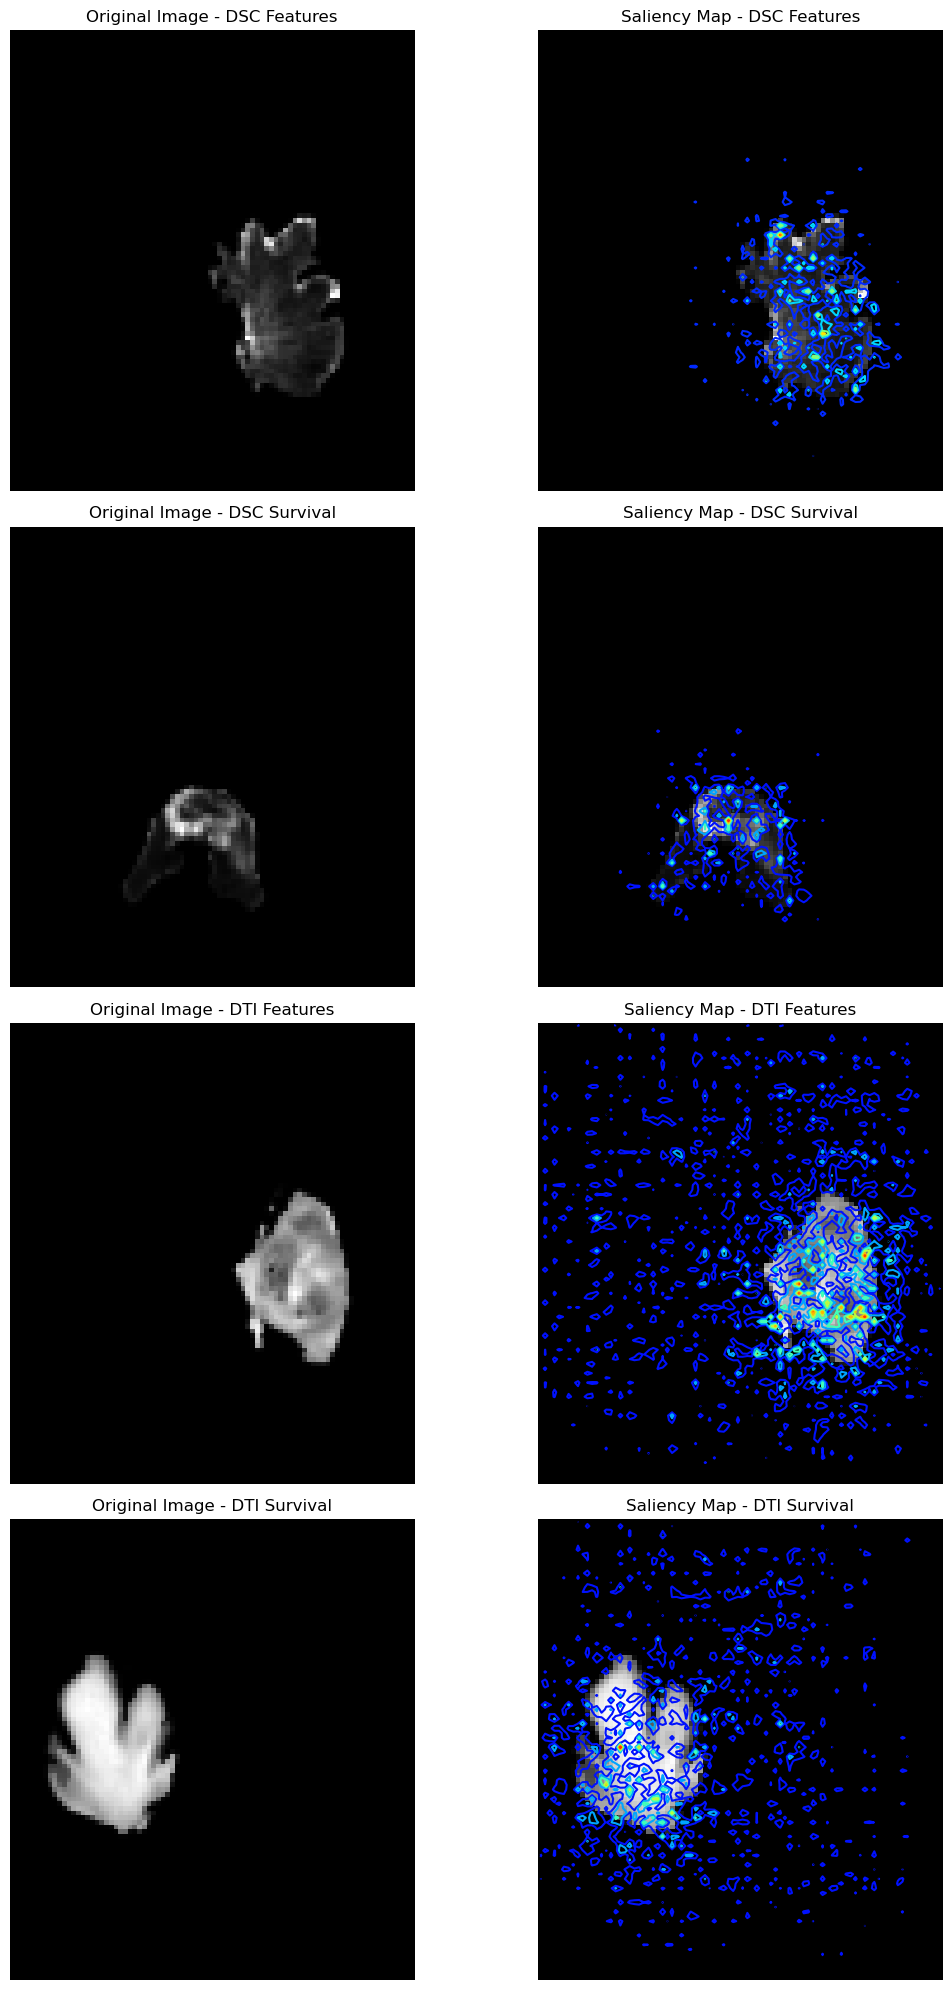

In [261]:
import matplotlib.pyplot as plt

# Create a figure with the appropriate number of subplots
num_plots = len(extracted_images)
fig, axes = plt.subplots(num_plots, 2, figsize=(12, 5 * num_plots))  # Two columns: original image and saliency map

# Ensure axes is always iterable, even when num_plots == 1
if num_plots == 1:
    axes = [axes]  # Convert to list if there's only one plot

# Plot each saliency map and the corresponding original image in the subplots
for i, data in enumerate(extracted_images):
    saliency_map = data['saliency_map']
    original_image = data['original_image']
    
    ax_image = axes[i][0]     # Left column: Original image
    ax_saliency = axes[i][1]  # Right column: Superimposed saliency map

    # Plot the original image (unaltered) on the left column
    ax_image.imshow(original_image, cmap='gray', interpolation='nearest')
    ax_image.set_title(f'Original Image - {data["model_name"]} {data["label_name"]}')
    ax_image.axis('off')  # Hide axes
    
    # Plot the saliency map contours superimposed on the original image on the right column
    ax_saliency.imshow(original_image, cmap='gray', interpolation='nearest')  # Display original image
    ax_saliency.contour(saliency_map, levels=6, cmap='jet')  # Superimpose contours on original image
    ax_saliency.set_title(f'Saliency Map - {data["model_name"]} {data["label_name"]}')
    ax_saliency.axis('off')  # Hide axes

    # Add outline to the saliency plot (border around the saliency map)
    ax_saliency.patch.set_edgecolor('black')  # Set the edge color to black
    ax_saliency.patch.set_linewidth(2) 

# Adjust layout and show the plot
plt.tight_layout()
plt.show()



In [262]:
with open(data_path+"Model_metrics.pkl", "rb") as f:
    all_metrics = pickle.load(f)


In [263]:
first_model_metrics = all_metrics['s_1_DSC']  # Metrics for DSC model with 'f' features

# Print the first sample's metrics (just an example)
print(first_model_metrics[0])

{'predicted': 186.70847, 'mse': 1.402233600616455, 'mape': 443.1303405761719, 'rmse': 1.1841593980789185, 'real_surv': 2207.0}


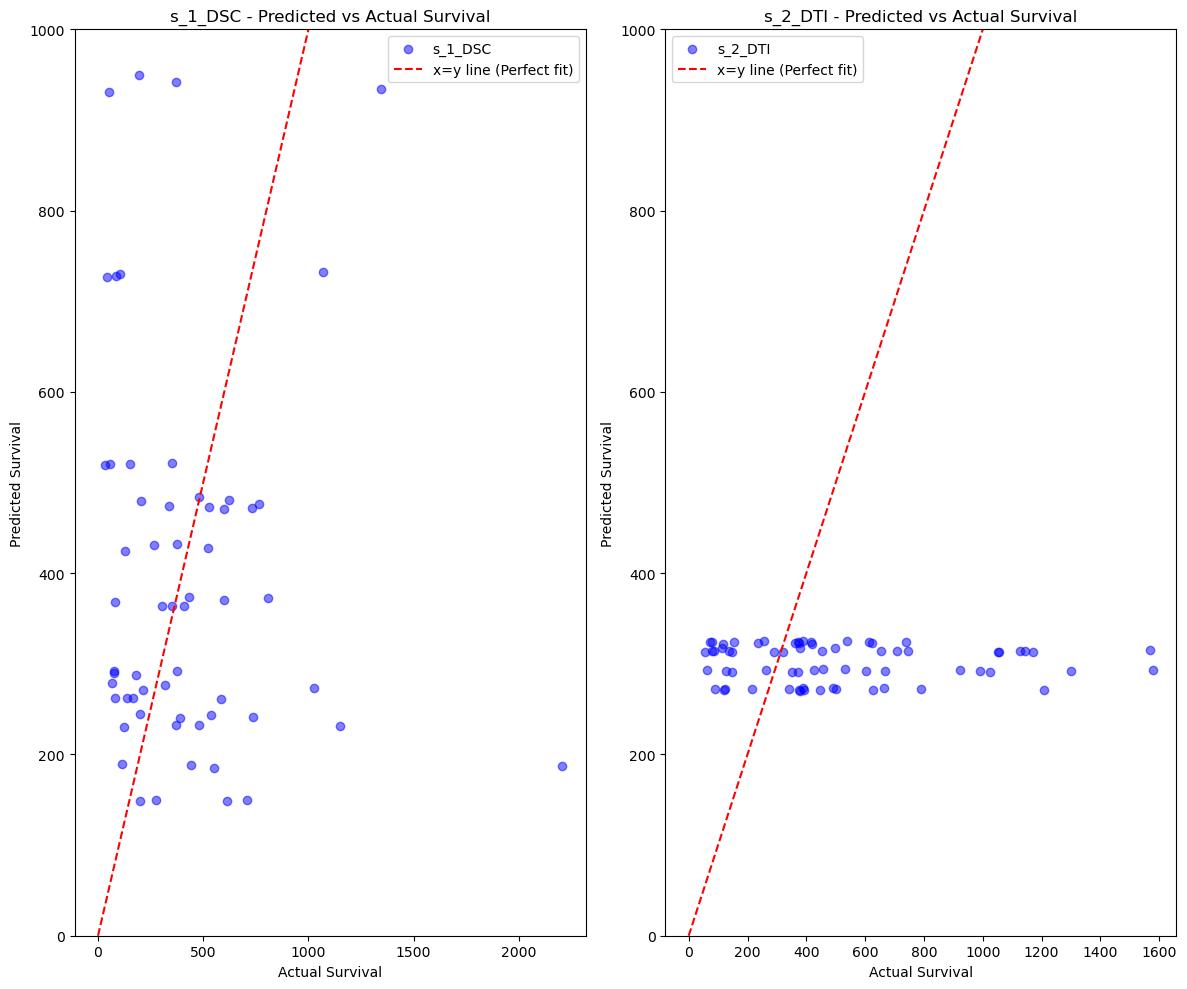

In [264]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare for plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# Flatten axes for easier iteration (to handle both rows and columns)
axes = axes.flatten()

# Define the model types for which we want to plot
model_types = ['s_1_DSC', 's_2_DTI']

# Plot the predictions vs actual survival for each model type
for i, model_type in enumerate(model_types):
    # Extract predicted and actual survival values for each model type
    predictions = [entry['predicted'] for entry in all_metrics[model_type]]  # Predicted survival for each sample
    actual = [entry['real_surv'] for entry in all_metrics[model_type]]  # Actual survival for each sample

    # Convert to numpy arrays for scatter plotting
    predictions = np.array(predictions)
    actual = np.array(actual)
    
    # Plotting the scatter data
    axes[i].scatter(actual, predictions, alpha=0.5, c='b', label=f'{model_type}')
    
    min_val = 0  # Start at 0
    max_val = max(max(actual), max(predictions))  # Set max to the number of data points

    # Plotting the perfect prediction line from (0,0) to (max_val, max_val)
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', label="x=y line (Perfect fit)")
    
    # Set titles and labels
    axes[i].set_title(f'{model_type} - Predicted vs Actual Survival')
    axes[i].set_xlabel('Actual Survival')
    axes[i].set_ylabel('Predicted Survival')
    axes[i].legend()
    axes[i].set_ylim(0,1000)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()
